In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import netCDF4 as nc
from scipy.interpolate import griddata
from scipy.spatial import cKDTree
from matplotlib.colors import to_rgb
import pickle
    
import sys
sys.path.append('/home/z5297792/UNSW-MRes/MRes/SEACOFS_dataset') 
from clim_functions import compute_core_mean, composite_eddy_velocity


In [2]:
df_eddies = pd.read_pickle('/srv/scratch/z5297792/SEACOFS_26yr_eddy_dataset/DOPPIO_SEACOFS_26yr_50m_vert_check/df_eddies_50m_vert_checked_processed.pkl')
df_tilt = pd.read_pickle('/srv/scratch/z5297792/SEACOFS_26yr_eddy_dataset/DOPPIO_SEACOFS_26yr_50m_vert_check/df_tilt_vert_checked.pkl')
df_eddies = df_eddies.merge(
    df_tilt[['Eddy', 'Day', 'TiltDis', 'TiltDir']],
    how='left',
    left_on=['Eddy', 'Day'],
    right_on=['Eddy', 'Day']
)
with open('/srv/scratch/z5297792/SEACOFS_26yr_eddy_dataset/DOPPIO_SEACOFS_26yr_50m_vert_check/dic_vert_doppio_50m_vert_checked.pkl', 'rb') as f:
    dic_vert = pickle.load(f)
df_eddies


,Eddy,Day,Cyc,lon,lat,ic,jc,xc,yc,w,...,q22,Rc,psi0,AR,R,Age,Date,fname,TiltDis,TiltDir
0,1,1462,CE,161.072036,-29.736582,261,274,928.181752,1356.070550,-0.000016,...,1.189040,118.032741,47.992205,1.434563,74.597458,38,1994-01-02,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,NaN,NaN
1,1,1463,CE,160.982386,-29.745743,260,274,920.121471,1352.093925,-0.000014,...,1.122134,115.905401,50.858737,1.417135,76.449111,38,1994-01-03,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,NaN,NaN
2,1,1464,CE,160.892701,-29.754904,258,273,912.061191,1348.117301,-0.000012,...,1.055228,113.778061,53.725269,1.413542,78.300764,38,1994-01-04,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,NaN,NaN
3,1,1465,CE,160.929437,-29.612368,258,276,911.162024,1364.461638,-0.000019,...,0.871468,111.650721,56.591801,1.411879,69.625773,38,1994-01-05,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,33.976810,184.917206
4,1,1466,CE,160.908986,-29.586156,258,277,908.463829,1366.554462,-0.000019,...,0.945071,115.925719,57.471319,1.597888,72.613632,38,1994-01-06,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,30.067059,181.174121
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125468,2937,10646,CE,153.739453,-37.488262,181,61,515.983450,302.961328,-0.000026,...,0.978558,61.312206,19.408106,1.110214,55.409919,28,2019-02-24,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,0.752304,4.278123
125469,2937,10647,CE,153.687115,-37.523299,181,60,512.684226,297.695084,-0.000027,...,0.972594,61.305207,19.388829,1.037331,44.896186,28,2019-02-25,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,1.165623,28.370419
125470,2937,10648,CE,153.699708,-37.537452,181,60,514.199660,296.590511,-0.000021,...,0.949624,61.298208,19.369553,1.055789,38.796956,28,2019-02-26,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,NaN,NaN
125471,2937,10649,CE,153.682657,-37.451789,180,62,510.019363,305.068558,-0.000019,...,0.937880,64.546558,19.604126,1.070344,40.028670,28,2019-02-27,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,NaN,NaN


In [3]:
fname = f'/srv/scratch/z3533156/26year_BRAN2020/outer_avg_01461.nc'
dataset = nc.Dataset(fname)
lon_rho = np.transpose(dataset.variables['lon_rho'], axes=(1, 0))
lat_rho = np.transpose(dataset.variables['lat_rho'], axes=(1, 0))
mask_rho = np.transpose(dataset.variables['mask_rho'], axes=(1, 0))
h = np.transpose(dataset.variables['h'], axes=(1, 0))
# f = np.transpose(dataset.variables['f'], axes=(1, 0))
angle = dataset.variables['angle'][0, 0]
z_r = np.load('/srv/scratch/z5297792/z_r.npy')
z_r = np.transpose(z_r, (1, 2, 0))
def distance(lat1, lon1, lat2, lon2):
    EARTH_RADIUS = 6357
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    return EARTH_RADIUS * 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
j_mid, i_mid = lon_rho.shape[1] // 2, lon_rho.shape[0] // 2
dx = distance(lat_rho[:-1, j_mid], lon_rho[:-1, j_mid],
              lat_rho[1:, j_mid], lon_rho[1:, j_mid])
dy = distance(lat_rho[i_mid, :-1], lon_rho[i_mid, :-1],
              lat_rho[i_mid, 1:], lon_rho[i_mid, 1:])
x_grid = np.insert(np.cumsum(dx), 0, 0)
y_grid = np.insert(np.cumsum(dy), 0, 0)
X_grid, Y_grid = np.meshgrid(x_grid, y_grid, indexing='ij')

levels_lat = [-40, -35, -30, -25]
levels_lon = [150, 155, 160]


In [4]:
# ---------------- six-bin region grid ----------------
region_mask_grid = (h < 4e3) & (X_grid < 400) & (lon_rho < 154.85) & (mask_rho == 1)

xsplit = 600
ysplit = 800

bin_grid = np.full(X_grid.shape, np.nan)

bin_grid[region_mask_grid & (Y_grid >= ysplit)] = 1
bin_grid[region_mask_grid & (Y_grid <  ysplit)] = 2

bin_grid[(~region_mask_grid) & (X_grid < xsplit) & (mask_rho == 1) & (Y_grid >= ysplit)] = 3
bin_grid[(~region_mask_grid) & (X_grid < xsplit) & (mask_rho == 1) & (Y_grid <  ysplit)] = 4

bin_grid[(X_grid >= xsplit) & (mask_rho == 1) & (Y_grid >= ysplit)] = 5
bin_grid[(X_grid >= xsplit) & (mask_rho == 1) & (Y_grid <  ysplit)] = 6

tree = cKDTree(
    np.column_stack([X_grid.ravel(), Y_grid.ravel()])
)

_, idx = tree.query(
    np.column_stack([df_eddies.xc, df_eddies.yc])
)

region_map = {
    1: 'S1',
    2: 'S2',
    3: 'U1',
    4: 'D1',
    5: 'U2',
    6: 'D2'
}

df_eddies['Region'] = (
    pd.Series(bin_grid.ravel()[idx])
      .map(region_map)
)


In [5]:
df_eddies['h'] = h[df_eddies.ic, df_eddies.jc]

df_eddies_shelf = df_eddies[df_eddies.Region.isin(['S1','S2'])]
df_eddies_shelf.Eddy.unique()


array([  10,   17,   21,   28,   31,   36,   42,   52,   63,   68,   84,
         89,   92,  105,  107,  108,  114,  115,  122,  127,  132,  139,
        140,  185,  191,  192,  196,  197,  199,  210,  215,  220,  224,
        225,  227,  241,  247,  254,  260,  268,  270,  274,  277,  279,
        283,  285,  297,  301,  311,  316,  324,  327,  356,  362,  365,
        372,  378,  381,  386,  394,  404,  406,  420,  422,  426,  433,
        434,  438,  440,  441,  444,  447,  449,  451,  459,  465,  473,
        481,  482,  492,  494,  498,  500,  503,  506,  509,  512,  516,
        518,  519,  520,  532,  533,  540,  542,  543,  549,  555,  569,
        570,  577,  581,  583,  591,  598,  599,  603,  627,  631,  642,
        646,  654,  657,  658,  659,  663,  674,  681,  695,  699,  702,
        707,  717,  721,  726,  729,  731,  741,  750,  751,  755,  759,
        770,  776,  789,  801,  806,  807,  819,  820,  821,  822,  825,
        826,  843,  847,  848,  851,  861,  865,  8

(-43.22017086446327, 1575.11000792028)

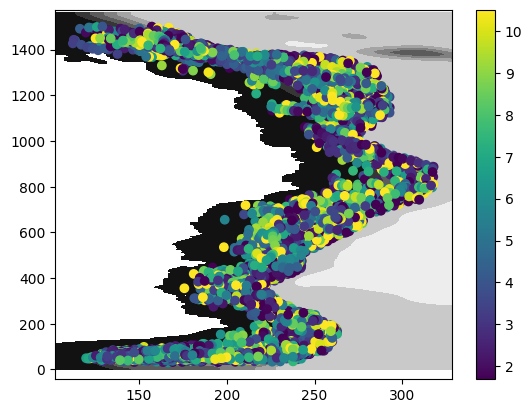

In [6]:

for eddy in df_eddies_shelf.Eddy.unique():
    df = df_eddies_shelf[df_eddies_shelf.Eddy==eddy]
    plt.scatter(df.xc, df.yc, c=df.TiltDis)
plt.colorbar()
xlim = plt.xlim()
ylim = plt.ylim()
plt.contourf(X_grid, Y_grid, np.where(mask_rho, h, np.nan), cmap='grey', zorder=0)
plt.xlim(xlim); plt.ylim(ylim)
# plt.axis('equal')


In [7]:
def plot_single_eddy_tilt(
    eddy, df_eddies,
    X_grid, Y_grid, h, mask_rho,
    gap=5, s=5, figsize=(7, 7),
    tilt_dir_offset=-20,
    ax=None,
    cbar=False,
    color=None,
    A_flag=True,
    cmap='gray',
    back_black=False,
    cbar_loc='right',
    alpha=1
):
    def point_b(a, r, theta_deg):
        theta_rad = np.radians(theta_deg)
        dx = r * np.sin(theta_rad)
        dy = r * np.cos(theta_rad)
        return a[0] - dx, a[1] - dy

    def darken(color, factor=0.7):
        r, g, b = to_rgb(color)
        return (r * factor, g * factor, b * factor)

    df_eddy = df_eddies.loc[df_eddies.Eddy.eq(eddy)].sort_values('Day').copy()

    if len(df_eddy) == 0:
        raise ValueError(f'Eddy {eddy} not found')

    cyc = df_eddy.Cyc.iloc[0]
    if color is None:
        color = 'c' if cyc == 'CE' else 'r'

    if ax is None:
        fig, ax = plt.subplots(figsize=figsize, constrained_layout=True)
    else:
        fig = ax.figure

    m = ax.contourf(
        X_grid, Y_grid,
        np.where(mask_rho, h / 1e3, np.nan),
        cmap=cmap
    )

    ax.plot(df_eddy.xc, df_eddy.yc, color=color, linewidth=0.5, zorder=1)

    for d, data in df_eddy.iterrows():

        x0, y0 = data.xc, data.yc
        tilt_dis = data.TiltDis
        tilt_dir = data.TiltDir

        if np.isnan(tilt_dis) or np.isnan(tilt_dir):
            ax.scatter(
                x0, y0,
                edgecolors=darken(color, 0.8),
                facecolors='none',
                s=15,
                zorder=3,
                alpha=alpha
            )
            continue

        xb, yb = point_b(
            [x0, y0],
            tilt_dis,
            (tilt_dir + tilt_dir_offset) % 360
        )

        ax.plot([x0, xb], [y0, yb], color=color, zorder=2, alpha=alpha)
        ax.scatter(x0, y0, color=darken(color, 0.8), s=s, zorder=3, alpha=alpha)

    if A_flag:
        ax.text(
            df_eddy.iloc[0].xc + 15,
            df_eddy.iloc[0].yc + 15,
            'A',
            color='r',
            fontsize=14
        )

    ax.set_title(f'{cyc}{eddy}')
    ax.set_xlabel('x (km)')
    ax.set_ylabel('y (km)')
    ax.set_aspect('equal', adjustable='box')
    ax.set_xlim(df_eddy.xc.min() - gap, df_eddy.xc.max() + gap)
    ax.set_ylim(df_eddy.yc.min() - gap, df_eddy.yc.max() + gap)

    # if cbar:
    #     cb = fig.colorbar(m, ax=ax, location=cbar_loc, shrink=0.7)
    #     cb.set_label('Bathymetry (km)')

    if back_black:
        ax.set_facecolor('k')

    return fig, ax, m
    

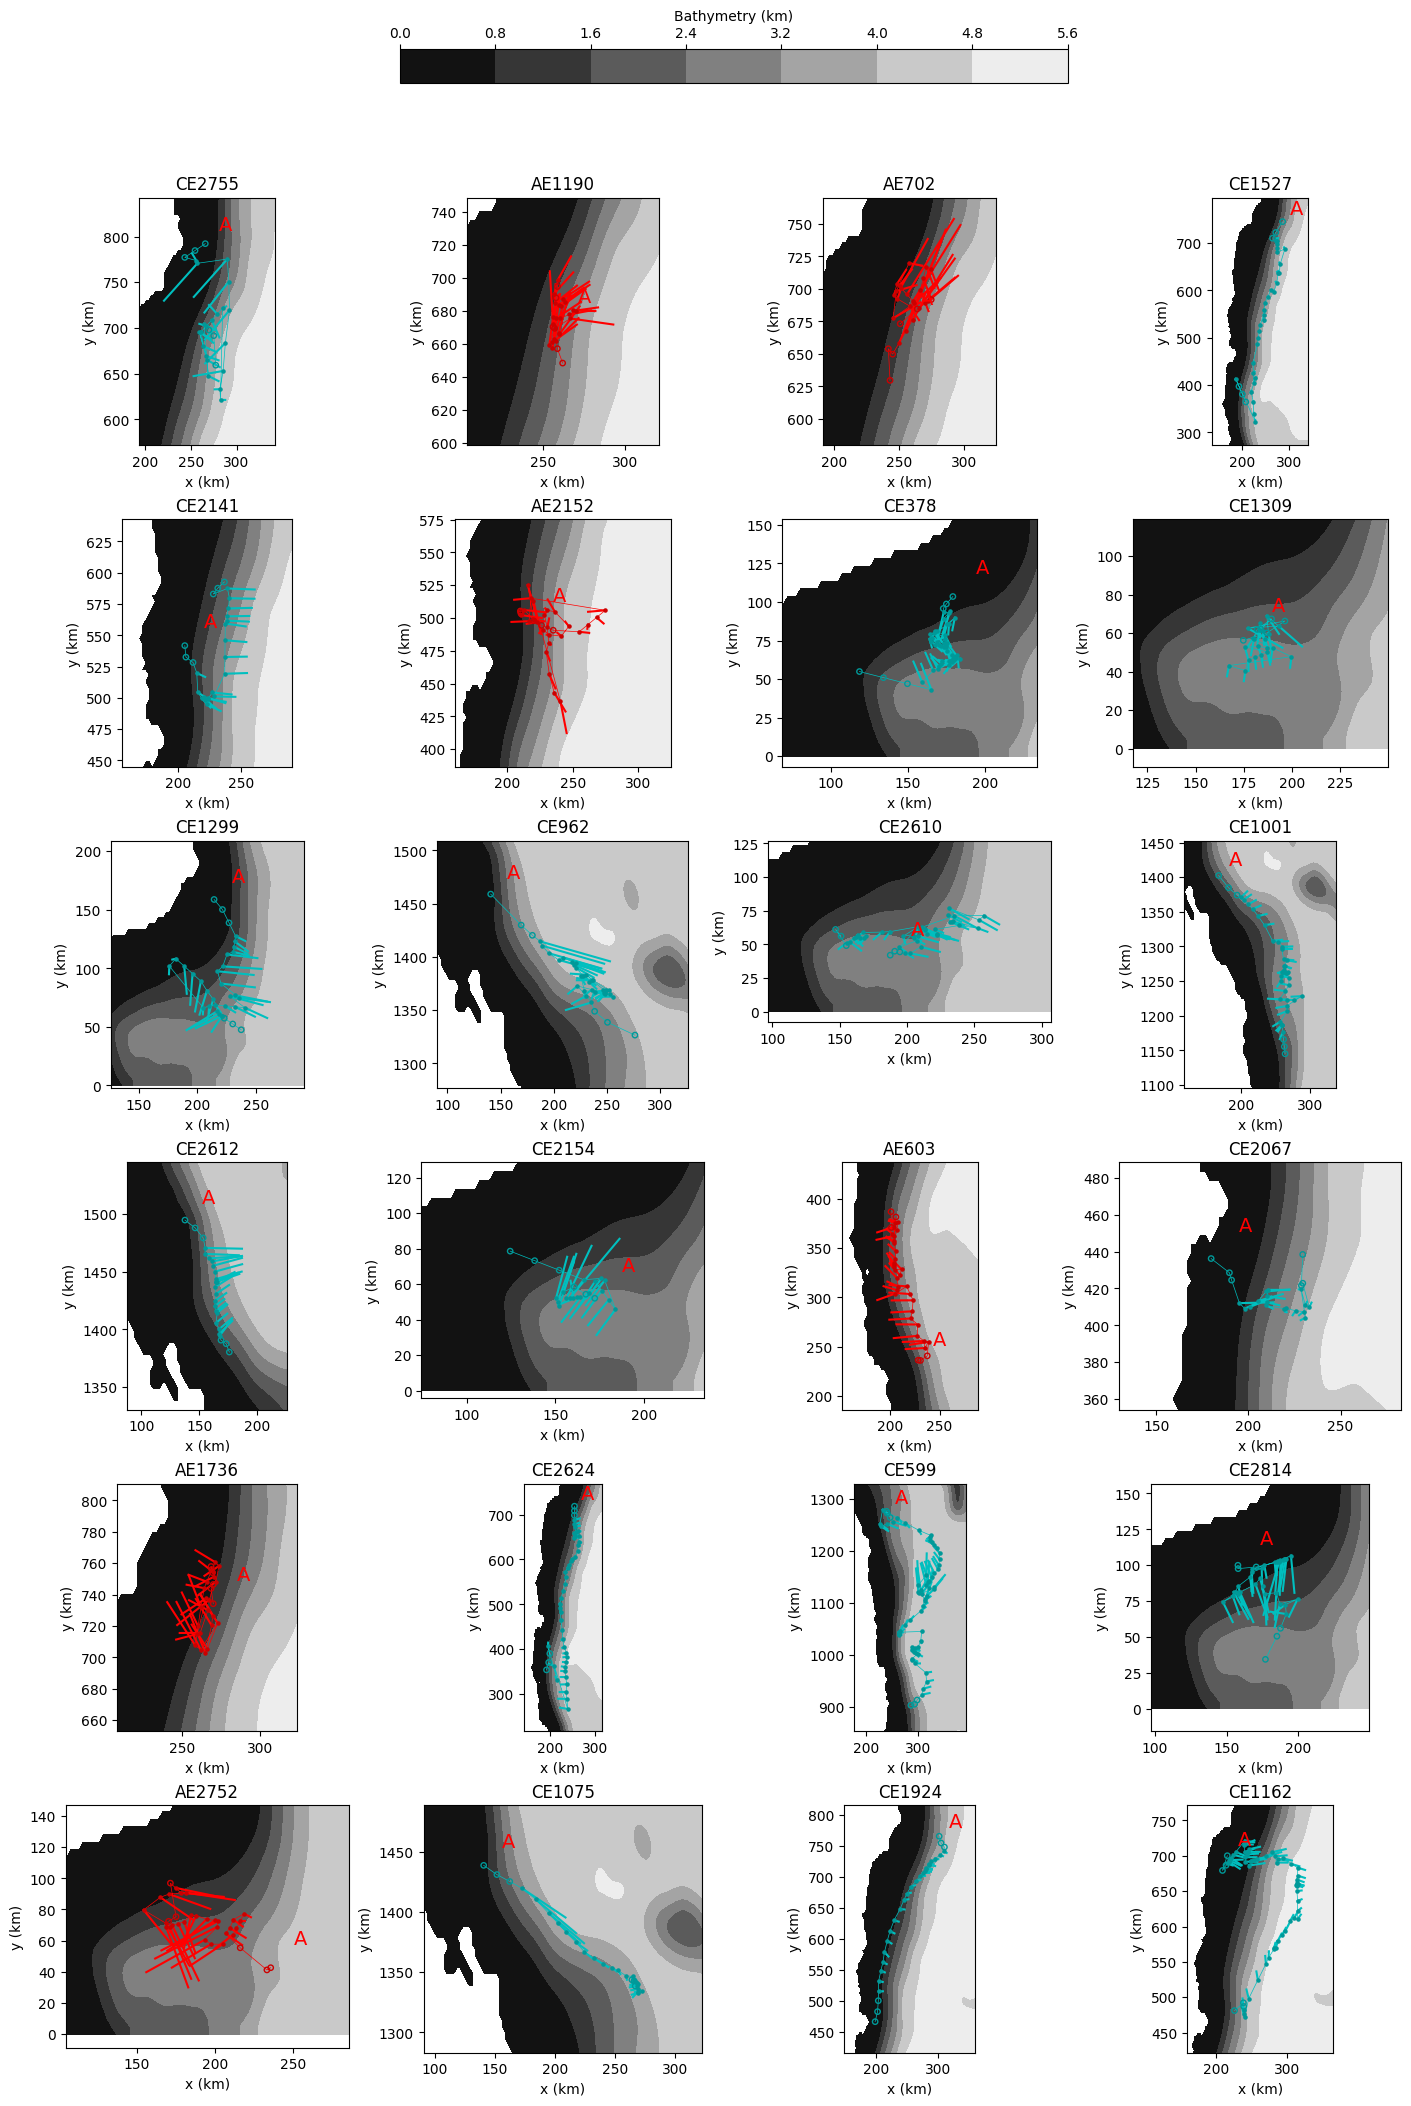

In [8]:
valid_eddies = (
    df_eddies_shelf
    .groupby('Eddy')['TiltDis']
    .apply(lambda x: (x.isna().sum() == 6) and (x.notna().sum() >= 7))
)

eddies = valid_eddies[valid_eddies].index.to_numpy()

# randomly select 24 eddies (6x4 subplot)
rng = np.random.default_rng()
eddies = rng.choice(eddies, size=24, replace=False)

fig, axs = plt.subplots(6, 4, figsize=(14, 21), constrained_layout=True)
axs = axs.ravel()

m = None
for ax, eddy in zip(axs, eddies):
    fig, ax, m = plot_single_eddy_tilt(
        eddy, df_eddies,
        X_grid, Y_grid, h, mask_rho,
        gap=50,
        ax=ax
    )

cbar = fig.colorbar(m, ax=axs, location='top', shrink=0.5)
cbar.set_label('Bathymetry (km)')


Text(0.5, 0, 'Tilt bearing - slope bearing [deg]')

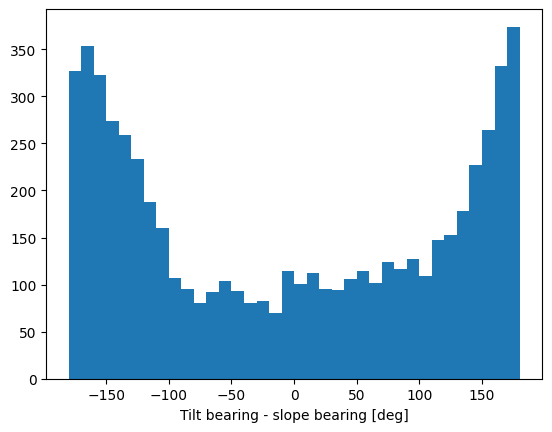

In [9]:
# rounded version
dhdy, dhdx = np.gradient(h, X_grid[:,0], Y_grid[0,:])

df_eddies_shelf = compute_core_mean( # mean value
    df_eddies_shelf,
    X_grid, Y_grid,
    mask_rho,
    fixed_field=dhdx,
    colname="gx"
)

df_eddies_shelf = compute_core_mean( # mean value
    df_eddies_shelf,
    X_grid, Y_grid,
    mask_rho,
    fixed_field=dhdy,
    colname="gy"
)

df_eddies_shelf['slope_bearing'] = (90 - np.degrees(np.arctan2(df_eddies_shelf.gx, df_eddies_shelf.gy)) + 20) % 360

df_eddies_shelf['theta'] = ((df_eddies_shelf.TiltDir - df_eddies_shelf.slope_bearing + 180) % 360) - 180

plt.hist(df_eddies_shelf.theta, bins=np.arange(-180, 181, 10))
plt.xlabel('Tilt bearing - slope bearing [deg]')


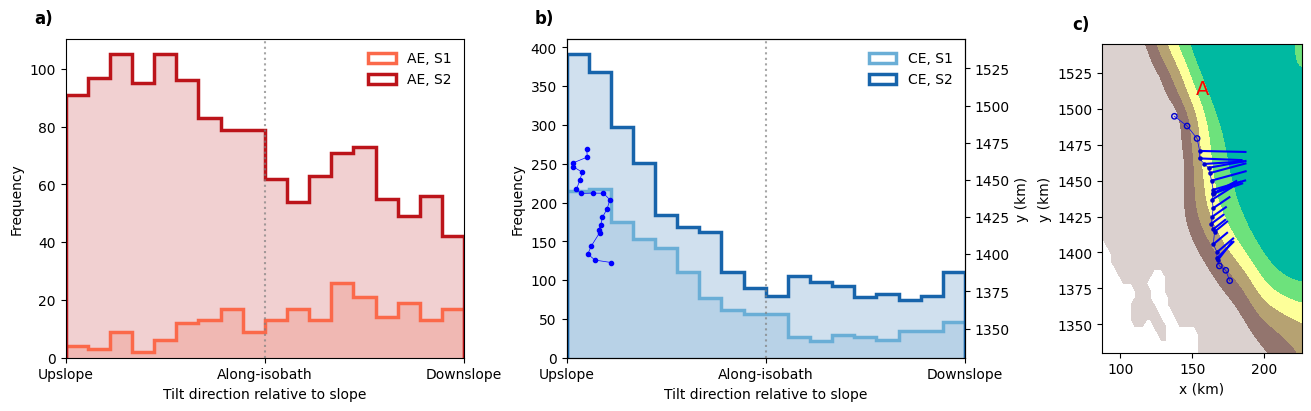

In [10]:
fig, axs = plt.subplots(
    1, 3,
    figsize=(13, 4),
    gridspec_kw={'width_ratios': [1, 1, .5]},
    constrained_layout=True
)

bins = np.arange(0, 181, 10)

reds = plt.get_cmap('Reds')
blues = plt.get_cmap('Blues')

for ax, cyc in zip(axs[:2], ['AE', 'CE']):

    df = df_eddies_shelf[df_eddies_shelf.Cyc == cyc]

    theta_s1 = 180 - np.abs(df.loc[df.Region == 'S1', 'theta'].dropna())
    theta_s2 = 180 - np.abs(df.loc[df.Region == 'S2', 'theta'].dropna())

    colors = [reds(0.5), reds(0.8)] if cyc == 'AE' else [blues(0.5), blues(0.8)]

    ax.hist(theta_s1, bins=bins, color=colors[0], alpha=0.2, histtype='stepfilled')
    ax.hist(theta_s2, bins=bins, color=colors[1], alpha=0.2, histtype='stepfilled')

    ax.hist(theta_s1, bins=bins, histtype='step', linewidth=2.5,
            color=colors[0], label=f'{cyc}, S1')
    ax.hist(theta_s2, bins=bins, histtype='step', linewidth=2.5,
            color=colors[1], label=f'{cyc}, S2')

    ax.axvline(90, color='grey', ls=':', alpha=0.7)

    ax.set_xticks([0, 90, 180])
    ax.set_xticklabels(['Upslope', 'Along-isobath', 'Downslope'])
    ax.set_xlim(0, 180)
    ax.legend(frameon=False)

    # if cyc == 'AE':
    #     ylim = ax.get_ylim()
    # else:
    #     ax.set_ylim(ylim)

    ax.set_ylabel('Frequency')
    ax.set_xlabel('Tilt direction relative to slope')

eddy = 2612 #1924 #1924 #2598

_, _, _ = plot_single_eddy_tilt(
    eddy, df_eddies_shelf,
    X_grid, Y_grid, h, mask_rho,
    gap=50,
    ax=axs[2],
    color='b',#blues(0.8),
    A_flag=True,
    cbar=True,
    cmap='terrain_r',
    back_black=False
)

axs[2].set_title('')

df = df_eddies_shelf[df_eddies_shelf.Eddy == eddy].copy()

ax1_twin = axs[1].twinx()
ax1_twin.plot(
    180 - df.theta.abs(),
    df.yc,
    '-o',
    color='b',
    markersize=3,
    linewidth=.5
)

ax1_twin.set_ylim(axs[2].get_ylim())
ax1_twin.set_ylabel('y (km)')
ax1_twin.tick_params(axis='y', labelright=True)

axs[0].text(-0.08, 1.05, 'a)', transform=axs[0].transAxes,
            fontsize=12, fontweight='bold')

axs[1].text(-0.08, 1.05, 'b)', transform=axs[1].transAxes,
            fontsize=12, fontweight='bold')

axs[2].text(-0.15, 1.05, 'c)', transform=axs[2].transAxes,
            fontsize=12, fontweight='bold')

plt.show()


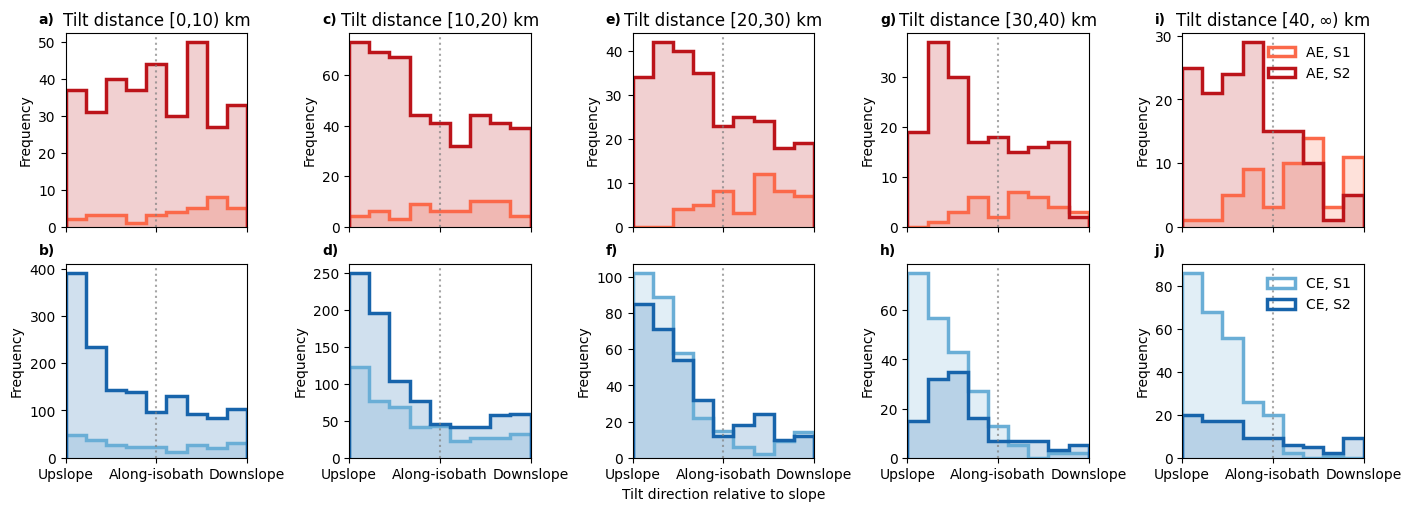

In [11]:
tilt_bins = [0, 10, 20, 30, 40, np.inf]
tilt_labels = [
    '[0,10) km',
    '[10,20) km',
    '[20,30) km',
    '[30,40) km',
    r'$[40,\infty)$ km'
]
tilt_labels = ['Tilt distance ' + i for i in tilt_labels]


df_plot = df_eddies_shelf.copy()
df_plot['TiltDis_bin'] = pd.cut(
    df_plot['TiltDis'],
    bins=tilt_bins,
    labels=tilt_labels,
    right=False
)

fig, axs = plt.subplots(
    2, len(tilt_labels),
    figsize=(14, 5),
    sharex=True,
    sharey=False,
    # gridspec_kw={'hspace': 0.05, 'wspace': 0.5}
    constrained_layout=True
)

bins = np.arange(0, 181, 20)

reds = plt.get_cmap('Reds')
blues = plt.get_cmap('Blues')

tags = ['a)', 'b)', 'c)', 'd)', 'e)', 'f)', 'g)', 'h)', 'i)', 'j)']
k = 0 
for i, tilt_bin in enumerate(tilt_labels):
    for j, cyc in enumerate(['AE', 'CE']):

        ax = axs[j, i]

        df = df_plot[
            (df_plot.Cyc == cyc) &
            (df_plot.TiltDis_bin == tilt_bin)
        ]

        theta_s1 = 180 - np.abs(df.loc[df.Region == 'S1', 'theta'].dropna())
        theta_s2 = 180 - np.abs(df.loc[df.Region == 'S2', 'theta'].dropna())

        colors = (
            [reds(0.5), reds(0.8)]
            if cyc == 'AE'
            else [blues(0.5), blues(0.8)]
        )

        ax.hist(theta_s1, bins=bins, color=colors[0],
                alpha=0.2, histtype='stepfilled')
        ax.hist(theta_s2, bins=bins, color=colors[1],
                alpha=0.2, histtype='stepfilled')

        ax.hist(theta_s1, bins=bins, histtype='step',
                linewidth=2.5, color=colors[0], label=f'{cyc}, S1')
        ax.hist(theta_s2, bins=bins, histtype='step',
                linewidth=2.5, color=colors[1], label=f'{cyc}, S2')

        ax.axvline(90, color='grey', ls=':', alpha=0.7)

        ax.set_xlim(0, 180)
        ax.set_xticks([0, 90, 180])
        ax.set_xticklabels(['Upslope', 'Along-isobath', 'Downslope'])

        if (j ==0):
            ax.set_title(f'{tilt_bin}')
        ax.set_ylabel('Frequency')

        if (i == 2) and (j == 1):
            ax.set_xlabel('Tilt direction relative to slope')

        if i == 4:
            ax.legend(frameon=False)

        ax.text(-0.15, 1.05, tags[k], transform=ax.transAxes,
            fontsize=10, fontweight='bold')
        k += 1

plt.show()


#### composite

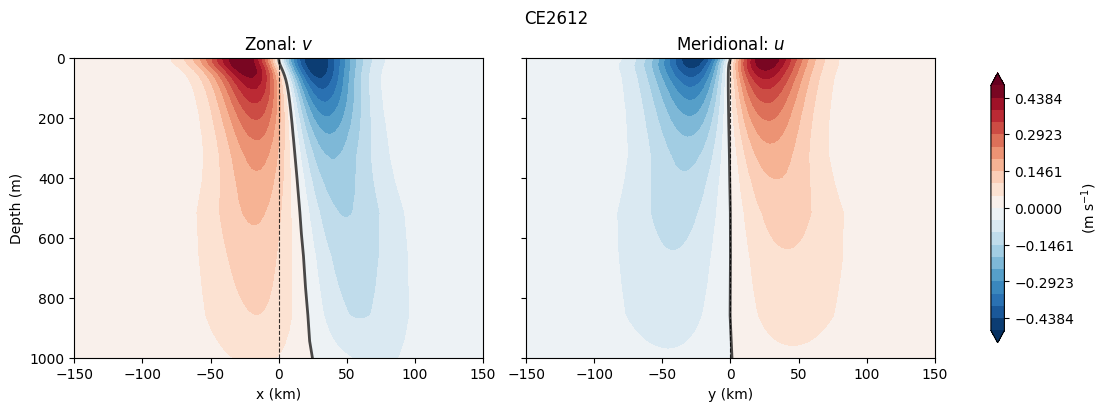

In [12]:
_ = composite_eddy_velocity(
    eddy=eddy,
    dic_vert=dic_vert,
    z_r=z_r,
    plot=True
)


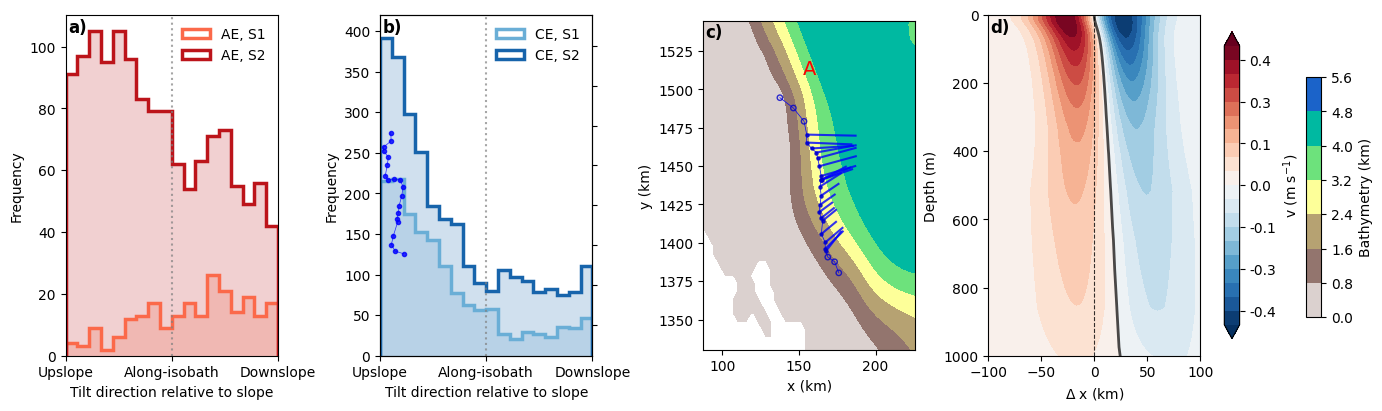

In [13]:
fig, axs = plt.subplots(
    1, 4,
    figsize=(13, 4),
    gridspec_kw={'width_ratios': [1, 1, 1, 1]},
    constrained_layout=True
)

bins = np.arange(0, 181, 10)

reds = plt.get_cmap('Reds')
blues = plt.get_cmap('Blues')

for ax, cyc in zip(axs[:2], ['AE', 'CE']):

    df = df_eddies_shelf[df_eddies_shelf.Cyc == cyc]

    theta_s1 = 180 - np.abs(df.loc[df.Region == 'S1', 'theta'].dropna())
    theta_s2 = 180 - np.abs(df.loc[df.Region == 'S2', 'theta'].dropna())

    colors = [reds(0.5), reds(0.8)] if cyc == 'AE' else [blues(0.5), blues(0.8)]

    ax.hist(theta_s1, bins=bins, color=colors[0], alpha=0.2, histtype='stepfilled')
    ax.hist(theta_s2, bins=bins, color=colors[1], alpha=0.2, histtype='stepfilled')

    ax.hist(theta_s1, bins=bins, histtype='step', linewidth=2.5,
            color=colors[0], label=f'{cyc}, S1')
    ax.hist(theta_s2, bins=bins, histtype='step', linewidth=2.5,
            color=colors[1], label=f'{cyc}, S2')

    ax.axvline(90, color='grey', ls=':', alpha=0.7)

    ax.set_xticks([0, 90, 180])
    ax.set_xticklabels(['Upslope', 'Along-isobath', 'Downslope'])
    ax.set_xlim(0, 180)
    ax.legend(frameon=False)

    # if cyc == 'AE':
    #     ylim = ax.get_ylim()
    # else:
    #     ax.set_ylim(ylim)

    ax.set_ylabel('Frequency')
    ax.set_xlabel('Tilt direction relative to slope')
axs[1].set_ylim(0, 420)

eddy = 2612 #1924 #1924 #2598

_, _, m = plot_single_eddy_tilt(
    eddy, df_eddies_shelf,
    X_grid, Y_grid, h, mask_rho,
    gap=50,
    ax=axs[2],
    color='b',#blues(0.8),
    A_flag=True,
    cbar=True,
    cmap='terrain_r',
    back_black=False,
    cbar_loc='right',
    alpha=.8
)
# fixed bathymetry colorbar axis
cax = fig.add_axes([1., 0.22, 0.012, 0.60])
cb = fig.colorbar(m, cax=cax)
cb.set_label('Bathymetry (km)')

axs[2].set_title('')

df = df_eddies_shelf[df_eddies_shelf.Eddy == eddy].copy()

ax1_twin = axs[1].twinx()
ax1_twin.plot(
    180 - df.theta.abs(),
    df.yc,
    '-o',
    color='b',
    markersize=3,
    linewidth=.5,
    alpha=.8
)

ax1_twin.set_ylim(axs[2].get_ylim())
# ax1_twin.set_ylabel('y (km)')
ax1_twin.set_yticklabels([])
ax1_twin.tick_params(axis='y', labelright=True)
# axs[2].set_yticklabels([])
# axs[2].set_ylabel('')

_ = composite_eddy_velocity(
    eddy=eddy,
    dic_vert=dic_vert,
    z_r=z_r,
    plot=True,
    plot_panel='zonal',
    ax=axs[3],
    add_cbar=True,
    xlim_km=100
)
axs[3].set_xlabel(r'$\Delta$ x (km)')
axs[3].set_title('')

# xt, yt = -0.08, 1.05
xt, yt = 0.01, .95
axs[0].text(xt, yt , 'a)', transform=axs[0].transAxes,
            fontsize=12, fontweight='bold')

axs[1].text(xt, yt , 'b)', transform=axs[1].transAxes,
            fontsize=12, fontweight='bold')

axs[2].text(xt, yt , 'c)', transform=axs[2].transAxes,
            fontsize=12, fontweight='bold')

axs[3].text(xt, yt , 'd)', transform=axs[3].transAxes,
            fontsize=12, fontweight='bold')

plt.show()
